In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import contextily as ctx
from geodatasets import get_path
import pandas as pd
from shapely.geometry import Point
from adjustText import adjust_text

In [9]:
# --------- Paths ---------
shapefiles_dir=Path("../MSWEP/shapefiles")
streamflow_stations_dir=Path("/inputs/data_updated_2/attributes/attributes_other.csv")

In [10]:
zip_files = sorted(shapefiles_dir.glob("*.zip"))
print(f"Found {len(zip_files)} zipped shapefiles:")
for f in zip_files:
    print(" -", f.name)


Found 17 zipped shapefiles:
 - bequelo.zip
 - durazno.zip
 - fraile_muerto.zip
 - mercedes.zip
 - paso_aguiar.zip
 - paso_baltasar.zip
 - paso_de_la_compania.zip
 - paso_de_las_piedras.zip
 - paso_de_las_piedras_rn.zip
 - paso_de_las_toscas.zip
 - paso_de_los_mellizos.zip
 - paso_del_borracho.zip
 - paso_manuel_diaz.zip
 - paso_mazangano.zip
 - picada_de_coelho.zip
 - sarandi_del_yi.zip
 - tacuarembo.zip


In [11]:
CAMELS_UY_dir={ #"1":"paso_de_la_compania",
               "2":"paso_de_las_piedras",
               "3":"paso_manuel_diaz",
            #    "4":"tacuarembo",
               "5":"paso_baltasar",
               "6":"paso_del_borracho",
               "7":"picada_de_coelho",
               "8":"paso_de_las_toscas",
               "9":"paso_aguiar",
               "10":"paso_mazangano",
               "11":"fraile_muerto",
            #    "12":"sarandi_del_yi",
            #    "13":"durazno",
            #    "14":"paso_de_los_mellizos",
               "15":"paso_de_las_piedras_rn",
               "16":"bequelo"}

In [12]:
# # Get a simple world land shapefile
# world_path = get_path("naturalearth.land")  # small polygons for land
# world = gpd.read_file(world_path).to_crs(epsg=4326)  # make sure it's in lat/lon

# ---- Load Natural Earth detailed countries (10m resolution) ----
url_countries_10m = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
countries = gpd.read_file(url_countries_10m).to_crs(epsg=4326)

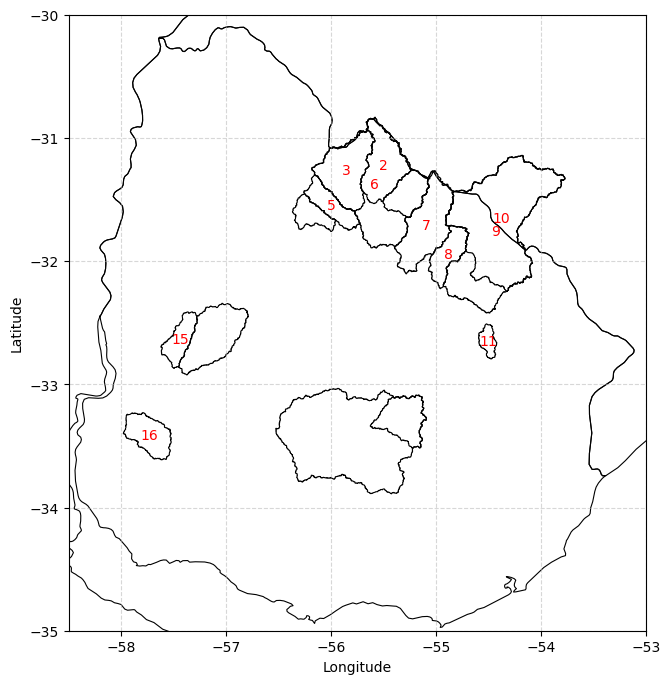

In [13]:
fig, ax = plt.subplots(figsize=(8,8))

# Plot country borders
countries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

# Plot each basin
for z in zip_files:
    if z.stem.lower() == "mercedes":
        continue
    gdf = gpd.read_file(f"zip://{z}")
    gdf.plot(ax=ax, edgecolor="k", facecolor="none", linewidth=0.8)

    # Find the number from the dictionary
    basin_number = None
    for num, name in CAMELS_UY_dir.items():
        if name.lower() == z.stem.lower():
            basin_number = num
            break
    
    # Add label at centroid(s)
    if basin_number is not None:
        # Some shapefiles may have multiple polygons
        for geom in gdf.geometry:
            x, y = geom.centroid.x, geom.centroid.y
            ax.text(x, y, basin_number, fontsize=10, color='red',
                    ha='center', va='center')

# ax.set_title("Basin Shapefiles")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

# ---- Limit map to Uruguay approximate bounds ----
# Uruguay approx: lon -58.5 to -53, lat -35 to -30
ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)

plt.show()

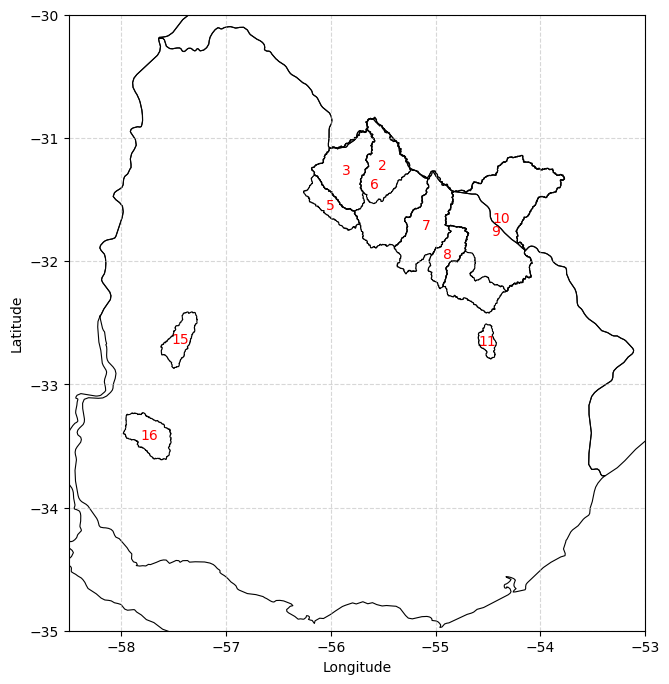

In [14]:
fig, ax = plt.subplots(figsize=(8,8))

# Plot country borders
countries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

# Build a set of active basin names from the (uncommented) dictionary
active_basins = {name.lower() for name in CAMELS_UY_dir.values()}

# Plot each basin
for z in zip_files:
    if z.stem.lower() not in active_basins:  # skips mercedes + commented-out basins
        continue
    gdf = gpd.read_file(f"zip://{z}")
    gdf.plot(ax=ax, edgecolor="k", facecolor="none", linewidth=0.8)

    # Find the number from the dictionary
    basin_number = None
    for num, name in CAMELS_UY_dir.items():
        if name.lower() == z.stem.lower():
            basin_number = num
            break
    
    # Add label at centroid(s)
    if basin_number is not None:
        for geom in gdf.geometry:
            x, y = geom.centroid.x, geom.centroid.y
            ax.text(x, y, basin_number, fontsize=10, color='red',
                    ha='center', va='center')
            
# ax.set_title("Basin Shapefiles")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

# ---- Limit map to Uruguay approximate bounds ----
# Uruguay approx: lon -58.5 to -53, lat -35 to -30
ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)

plt.show()

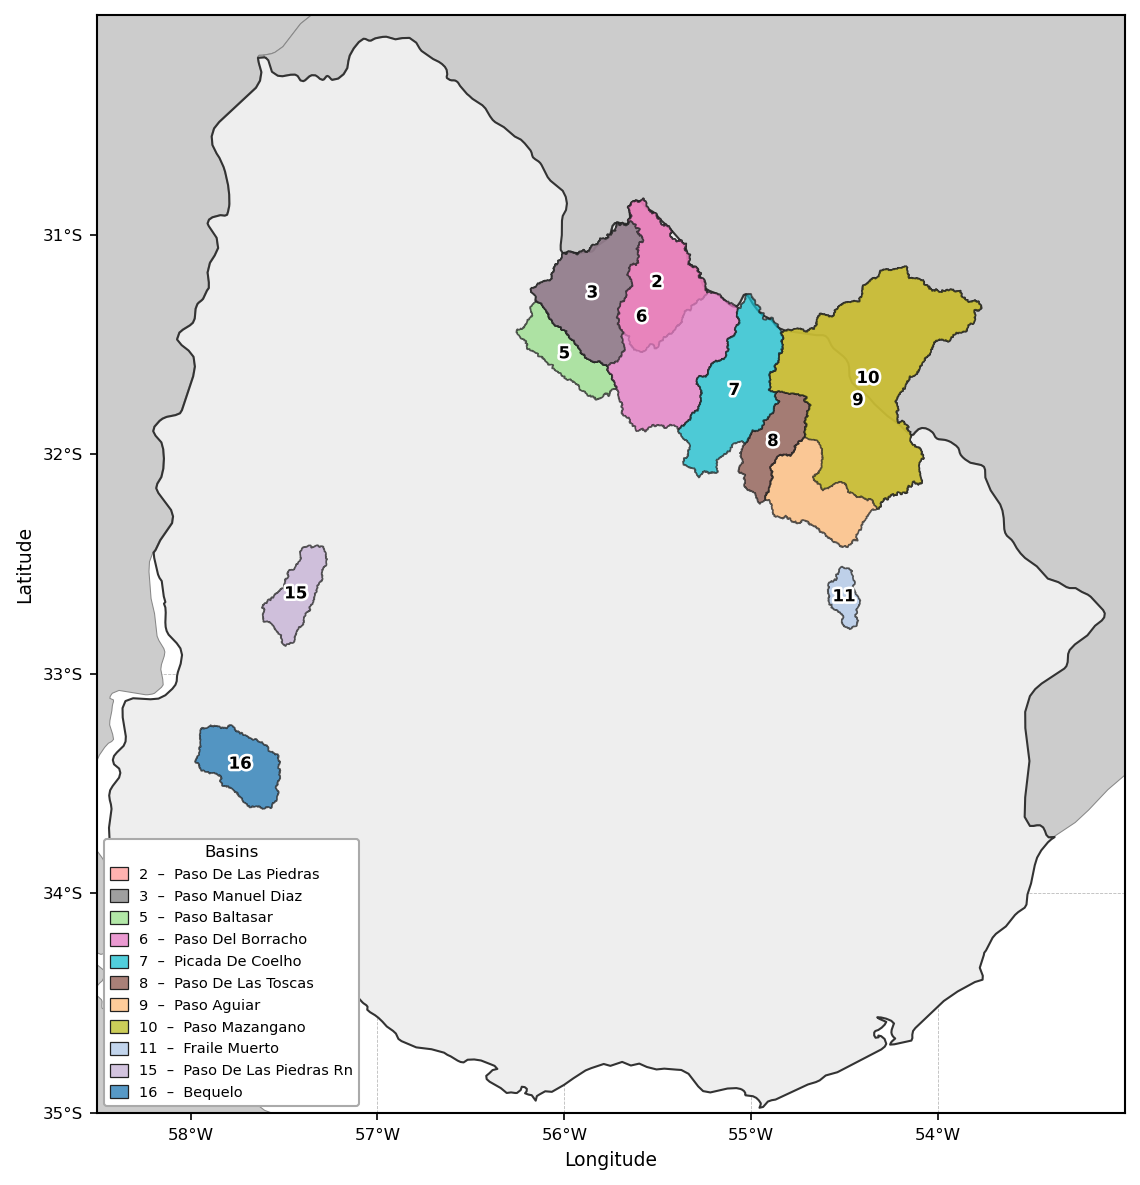

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---- Neighboring countries (grayscale) ----
countries[countries["NAME"] != "Uruguay"].plot(
    ax=ax, facecolor="#cccccc", edgecolor="#888888", linewidth=0.5
)

# ---- Uruguay (light gray) ----
uruguay = countries[countries["NAME"] == "Uruguay"]
uruguay.plot(ax=ax, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.0)

# ---- Colors for basins (qualitative, colorblind-friendly) ----
active_basins = {name.lower() for name in CAMELS_UY_dir.values()}
n_basins = len(active_basins)
cmap = plt.get_cmap("tab20")
basin_colors = {name: cmap(i / n_basins) for i, name in enumerate(sorted(active_basins))}

legend_handles = []

# ---- Plot each basin ----
for z in zip_files:
    stem = z.stem.lower()
    if stem not in active_basins:
        continue

    gdf = gpd.read_file(f"zip://{z}")
    color = basin_colors[stem]
    gdf.plot(ax=ax, edgecolor="#222222", facecolor=color, linewidth=0.8, alpha=0.75)

    basin_number = None
    for num, name in CAMELS_UY_dir.items():
        if name.lower() == stem:
            basin_number = num
            break

    if basin_number is not None:
        for geom in gdf.geometry:
            x, y = geom.centroid.x, geom.centroid.y
            ax.text(
                x, y, basin_number,
                fontsize=8, fontweight="bold", color="black",
                ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
            )

    legend_handles.append(
        mpatches.Patch(
            facecolor=(*color[:3], 0.75), edgecolor="#222222", linewidth=0.6,
            label=f"{basin_number}  –  {z.stem.replace('_', ' ').title()}"
        )
    )

# ---- Legend ----
legend_handles_sorted = sorted(
    legend_handles, key=lambda h: int(h.get_label().split()[0])
)
ax.legend(
    handles=legend_handles_sorted,
    loc="lower left", fontsize=7, title="Basins", title_fontsize=8,
    framealpha=1.0, edgecolor="#aaaaaa", frameon=True,
    handlelength=1.2, handleheight=1.0,
)

# ---- Gridlines ----
gl_x = np.arange(-58, -53, 1)
gl_y = np.arange(-35, -30, 1)
for x in gl_x:
    ax.axvline(x, color="#bbbbbb", linewidth=0.4, linestyle="--", zorder=0)
for y in gl_y:
    ax.axhline(y, color="#bbbbbb", linewidth=0.4, linestyle="--", zorder=0)

# ---- Axis ticks and labels ----
ax.set_xticks(gl_x)
ax.set_yticks(gl_y)
ax.set_xticklabels([f"{abs(x)}°W" for x in gl_x], fontsize=8)
ax.set_yticklabels([f"{abs(y)}°S" for y in gl_y], fontsize=8)
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)

# ---- Clean frame ----
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor("black")

ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)

plt.tight_layout()
# plt.savefig("basin_map.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

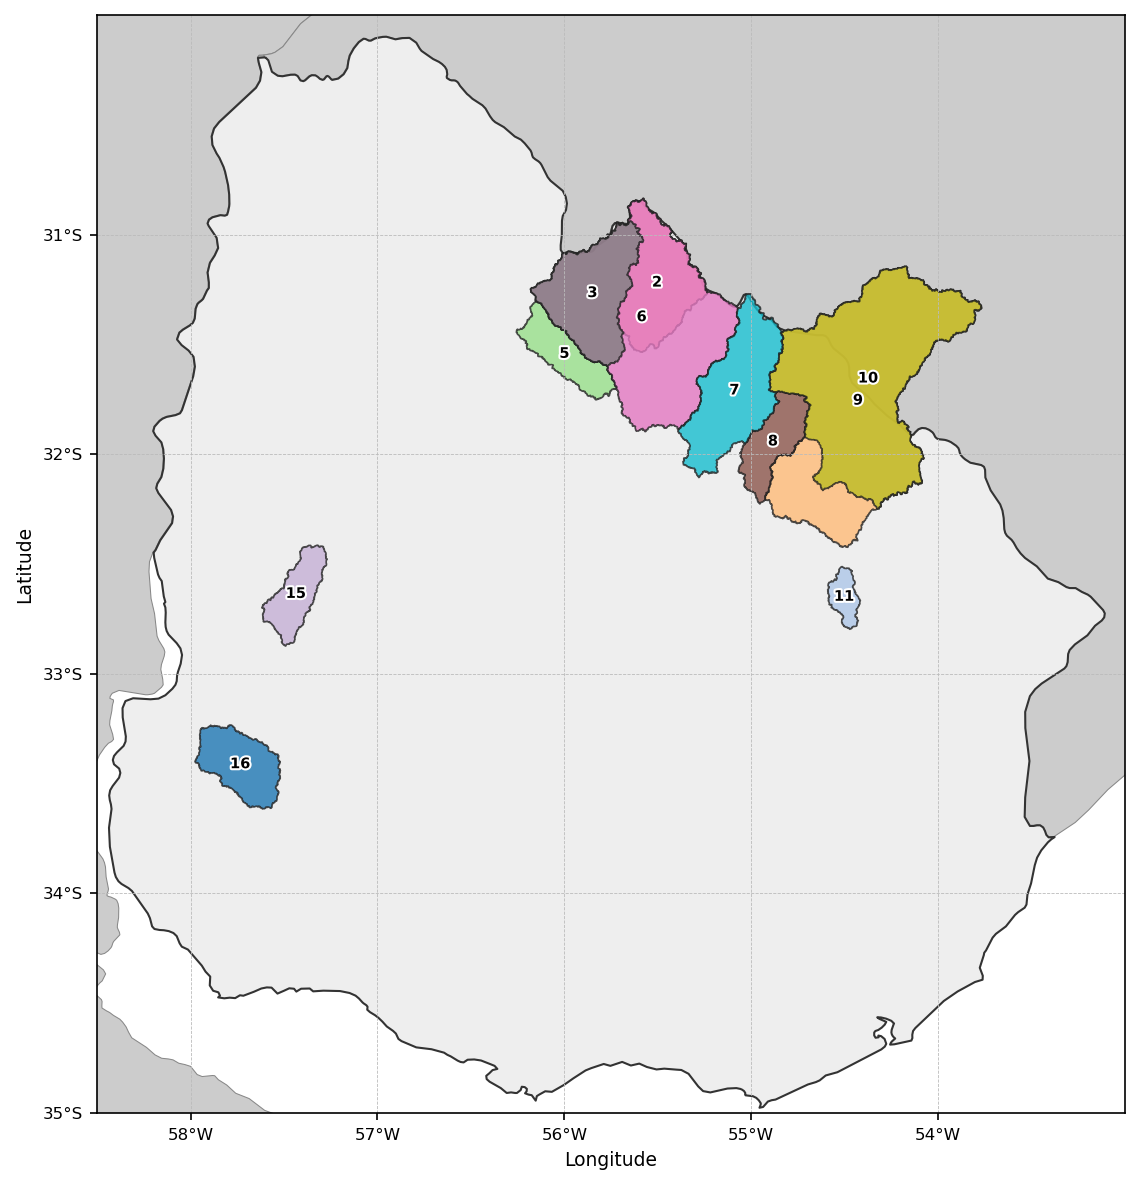

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
import numpy as np

# ---- Setup ----
active_basins = {name.lower(): num for num, name in CAMELS_UY_dir.items()}
basin_names   = sorted(active_basins.keys())
cmap          = plt.get_cmap("tab20")
basin_colors  = {name: cmap(i / len(basin_names)) for i, name in enumerate(basin_names)}

# ---- Load all basin GDFs once ----
basin_gdfs = {}
for z in zip_files:
    stem = z.stem.lower()
    if stem in active_basins:
        basin_gdfs[stem] = gpd.read_file(f"zip://{z}")

# ---- Figure ----
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---- Basemap ----
countries[countries["NAME"] != "Uruguay"].plot(ax=ax, facecolor="#cccccc", edgecolor="#888888", linewidth=0.5)
countries[countries["NAME"] == "Uruguay"].plot(ax=ax, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.0)

# ---- Basins ----
legend_handles = []
for stem, gdf in basin_gdfs.items():
    num   = active_basins[stem]
    color = basin_colors[stem]
    gdf.plot(ax=ax, facecolor=color, edgecolor="#222222", linewidth=0.8, alpha=0.80)
    for geom in gdf.geometry:
        ax.text(*geom.centroid.coords[0], num, fontsize=7, fontweight="bold",
                ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    legend_handles.append(mpatches.Patch(
        facecolor=(*color[:3], 0.80), edgecolor="#222222",
        label=f"{num} – {stem.replace('_', ' ').title()}"
    ))

# # ---- Legend ----
# legend_handles.sort(key=lambda h: int(h.get_label().split("–")[0]))
# ax.legend(handles=legend_handles, fontsize=7, title="Basins", title_fontsize=8,
#           loc="lower left", framealpha=1.0, edgecolor="#aaaaaa")

# ---- Axes ----
ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)
ax.set_xticks(np.arange(-58, -53, 1))
ax.set_yticks(np.arange(-35, -30, 1))
ax.set_xticklabels([f"{abs(x)}°W" for x in np.arange(-58, -53, 1)], fontsize=8)
ax.set_yticklabels([f"{abs(y)}°S" for y in np.arange(-35, -30, 1)], fontsize=8)
ax.grid(linestyle="--", linewidth=0.4, color="#bbbbbb", zorder=0)

plt.tight_layout()
# plt.savefig("basin_map.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

/tmp/ipykernel_5974/3601410442.py:86: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_9  = gdf_9.geometry.unary_union
/tmp/ipykernel_5974/3601410442.py:87: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_10 = gdf_10.geometry.unary_union


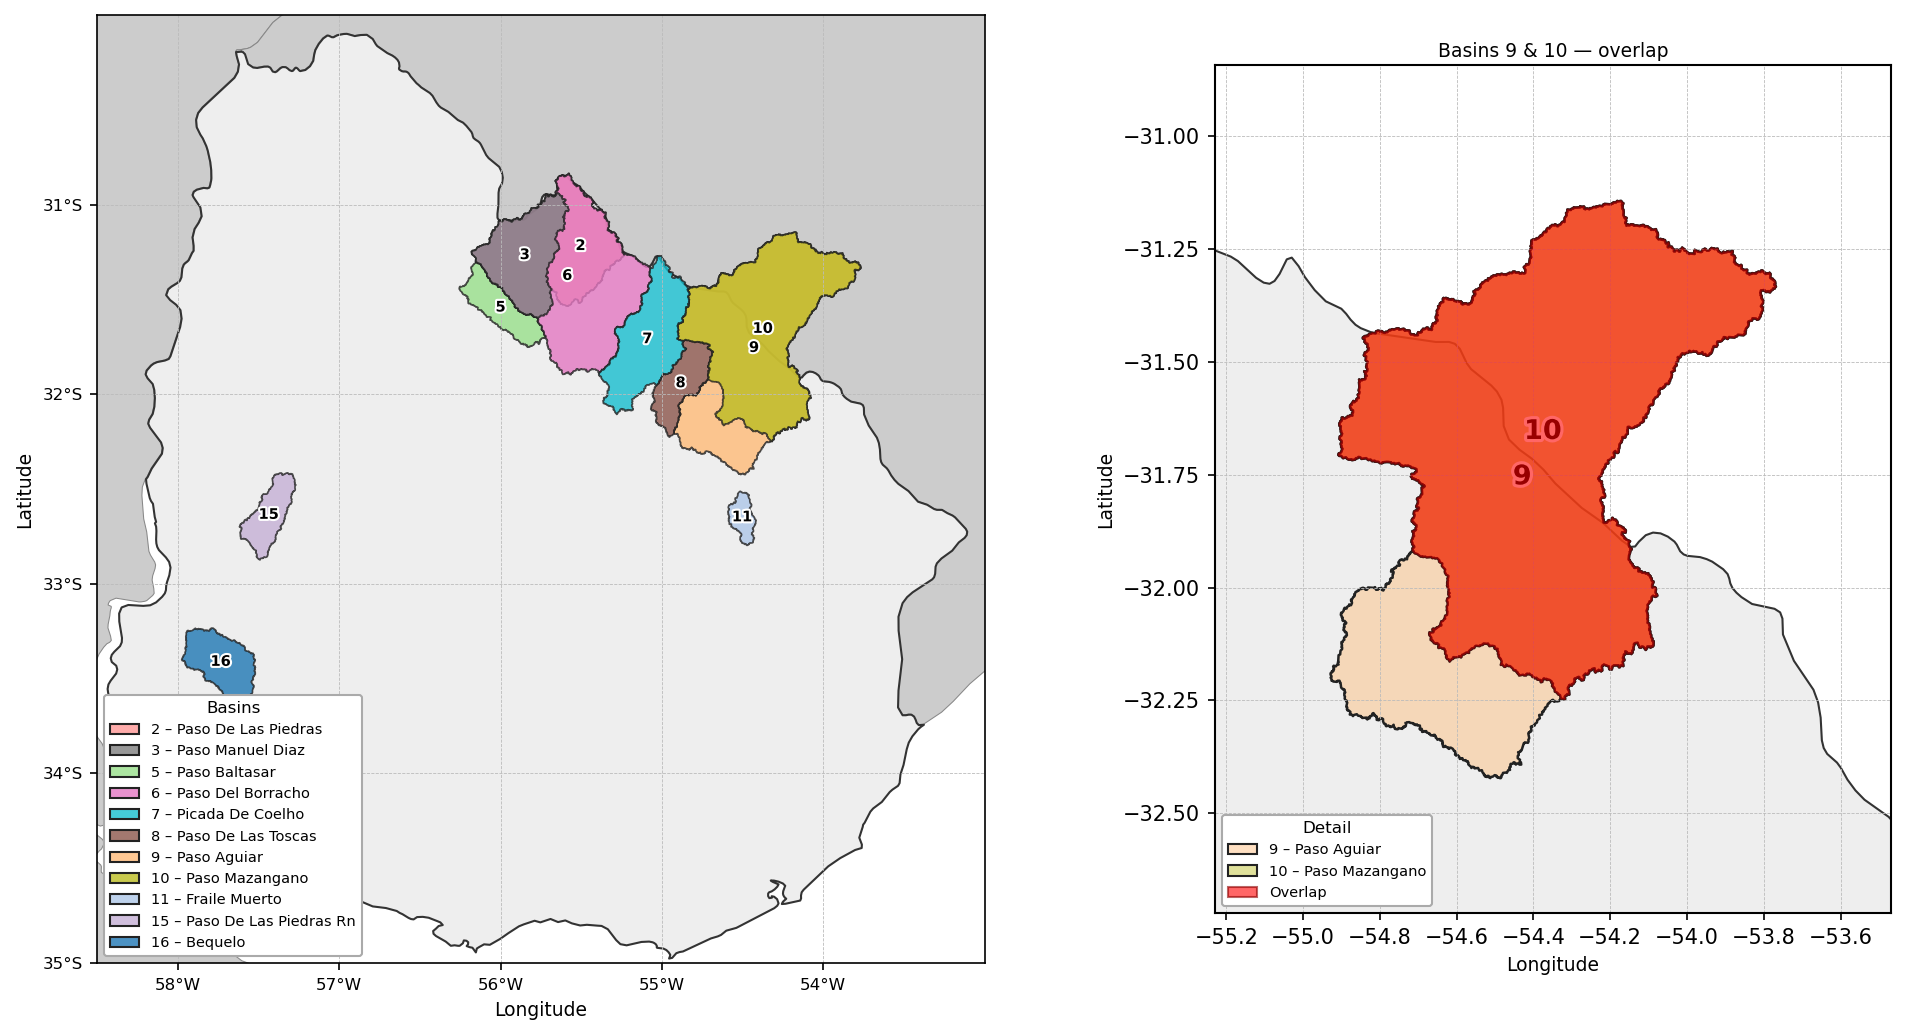

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
import numpy as np

# ---- Setup ----
active_basins = {name.lower(): num for num, name in CAMELS_UY_dir.items()}
basin_names   = sorted(active_basins.keys())
cmap          = plt.get_cmap("tab20")
basin_colors  = {name: cmap(i / len(basin_names)) for i, name in enumerate(basin_names)}

# ---- Load all basin GDFs once ----
basin_gdfs = {}
for z in zip_files:
    stem = z.stem.lower()
    if stem in active_basins:
        basin_gdfs[stem] = gpd.read_file(f"zip://{z}")

# ---- Figure: map left, overlap detail right ----
fig, (ax_map, ax_over) = plt.subplots(1, 2, figsize=(14, 7), dpi=150,
                                       gridspec_kw={"width_ratios": [2, 1]})
fig.patch.set_facecolor("white")
plt.subplots_adjust(wspace=0.08)

# ========================
# LEFT: MAIN MAP
# ========================
ax_map.set_facecolor("white")
countries[countries["NAME"] != "Uruguay"].plot(ax=ax_map, facecolor="#cccccc", edgecolor="#888888", linewidth=0.5)
countries[countries["NAME"] == "Uruguay"].plot(ax=ax_map, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.0)

legend_handles = []
for stem, gdf in basin_gdfs.items():
    num   = active_basins[stem]
    color = basin_colors[stem]
    gdf.plot(ax=ax_map, facecolor=color, edgecolor="#222222", linewidth=0.8, alpha=0.80)
    for geom in gdf.geometry:
        ax_map.text(*geom.centroid.coords[0], num, fontsize=7, fontweight="bold",
                    ha="center", va="center",
                    path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    legend_handles.append(mpatches.Patch(
        facecolor=(*color[:3], 0.80), edgecolor="#222222",
        label=f"{num} – {stem.replace('_', ' ').title()}"
    ))

legend_handles.sort(key=lambda h: int(h.get_label().split("–")[0]))
ax_map.legend(handles=legend_handles, fontsize=7, title="Basins", title_fontsize=8,
              loc="lower left", framealpha=1.0, edgecolor="#aaaaaa")

ax_map.set_xlim(-58.5, -53)
ax_map.set_ylim(-35, -30)
ax_map.set_xlabel("Longitude", fontsize=9)
ax_map.set_ylabel("Latitude", fontsize=9)
ax_map.set_xticks(np.arange(-58, -53, 1))
ax_map.set_yticks(np.arange(-35, -30, 1))
ax_map.set_xticklabels([f"{abs(x)}°W" for x in np.arange(-58, -53, 1)], fontsize=8)
ax_map.set_yticklabels([f"{abs(y)}°S" for y in np.arange(-35, -30, 1)], fontsize=8)
ax_map.grid(linestyle="--", linewidth=0.4, color="#bbbbbb", zorder=0)

# ========================
# RIGHT: OVERLAP PANEL
# ========================
ax_over.set_facecolor("white")

# Uruguay outline for context
countries[countries["NAME"] == "Uruguay"].plot(
    ax=ax_over, facecolor="#eeeeee", edgecolor="#333333", linewidth=1.0
)

# ---- Get the two GDFs ----
num_to_stem = {v: k for k, v in active_basins.items()}
stem_9  = num_to_stem["9"]
stem_10 = num_to_stem["10"]
gdf_9   = basin_gdfs[stem_9]
gdf_10  = basin_gdfs[stem_10]

color_9  = basin_colors[stem_9]
color_10 = basin_colors[stem_10]

# ---- Plot basin 9 and 10 with transparency ----
gdf_9.plot(ax=ax_over,  facecolor=(*color_9[:3],  0.45), edgecolor="#222222", linewidth=1.2)
gdf_10.plot(ax=ax_over, facecolor=(*color_10[:3], 0.45), edgecolor="#222222", linewidth=1.2)

# ---- Compute and highlight intersection ----
geom_9  = gdf_9.geometry.unary_union
geom_10 = gdf_10.geometry.unary_union
intersection = geom_9.intersection(geom_10)

if not intersection.is_empty:
    inter_gdf = gpd.GeoDataFrame(geometry=[intersection], crs=gdf_9.crs)
    inter_gdf.plot(ax=ax_over, facecolor="red", edgecolor="darkred",
                   linewidth=1.0, alpha=0.6, zorder=5)

# ---- Labels ----
for geom in gdf_9.geometry:
    ax_over.text(*geom.centroid.coords[0], "9", fontsize=13, fontweight="bold",
                 ha="center", va="center",
                 path_effects=[pe.withStroke(linewidth=3, foreground="white")])
for geom in gdf_10.geometry:
    ax_over.text(*geom.centroid.coords[0], "10", fontsize=13, fontweight="bold",
                 ha="center", va="center",
                 path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# ---- Legend for overlap panel ----
ax_over.legend(handles=[
    mpatches.Patch(facecolor=(*color_9[:3],  0.45), edgecolor="#222222", label="9 – Paso Aguiar"),
    mpatches.Patch(facecolor=(*color_10[:3], 0.45), edgecolor="#222222", label="10 – Paso Mazangano"),
    mpatches.Patch(facecolor="red",                 edgecolor="darkred",  alpha=0.6, label="Overlap"),
], fontsize=7, title="Detail", title_fontsize=8, loc="lower left",
   framealpha=1.0, edgecolor="#aaaaaa")

# ---- Zoom to the two basins ----
minx, miny, maxx, maxy = geom_9.union(geom_10).bounds
pad = 0.3
ax_over.set_xlim(minx - pad, maxx + pad)
ax_over.set_ylim(miny - pad, maxy + pad)
ax_over.set_xlabel("Longitude", fontsize=9)
ax_over.set_ylabel("Latitude", fontsize=9)
ax_over.set_title("Basins 9 & 10 — overlap", fontsize=9, pad=4)
ax_over.grid(linestyle="--", linewidth=0.4, color="#bbbbbb", zorder=0)
for spine in ax_over.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor("black")

plt.tight_layout()
# plt.savefig("basin_map.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## Map with precip and streamflow stations

In [17]:
attributes=pd.read_csv(streamflow_stations_dir)
attributes = attributes[attributes['gauge_id'].str.startswith('CAMELS_UY_')]
attributes.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
15960,CAMELS_UY_1,Paso de la Compania,Uruguay,-31.577506,-55.465611,1044.805388
15961,CAMELS_UY_2,Paso de las Piedras,Uruguay,-31.530457,-55.584818,1923.084030
15962,CAMELS_UY_3,Paso Manuel Diaz,Uruguay,-31.529667,-55.686583,2212.331158
15963,CAMELS_UY_4,Tacuarembo,Uruguay,-31.529667,-55.686583,673.286140
15964,CAMELS_UY_5,Paso Baltasar,Uruguay,-31.728558,-55.769773,917.609589


In [18]:
# Create geometry column from lat/lon
geometry = [Point(xy) for xy in zip(attributes['gauge_lon'], attributes['gauge_lat'])]

# Convert to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(attributes, geometry=geometry)

In [19]:
stations_gdf

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area,geometry
15960,CAMELS_UY_1,Paso de la Compania,Uruguay,-31.577506,-55.465611,1044.805388,POINT (-55.46561 -31.57751)
15961,CAMELS_UY_2,Paso de las Piedras,Uruguay,-31.530457,-55.584818,1923.084030,POINT (-55.58482 -31.53046)
15962,CAMELS_UY_3,Paso Manuel Diaz,Uruguay,-31.529667,-55.686583,2212.331158,POINT (-55.68658 -31.52967)
15963,CAMELS_UY_4,Tacuarembo,Uruguay,-31.529667,-55.686583,673.286140,POINT (-55.68658 -31.52967)
15964,CAMELS_UY_5,Paso Baltasar,Uruguay,-31.728558,-55.769773,917.609589,POINT (-55.76977 -31.72856)
15965,CAMELS_UY_6,Paso del Borracho,Uruguay,-31.876083,-55.471139,6601.754962,POINT (-55.47114 -31.87608)
15966,CAMELS_UY_7,Paso de Coelho,Uruguay,-32.033324,-55.367013,2419.341041,POINT (-55.36701 -32.03332)
15967,CAMELS_UY_8,Paso de las Toscas,Uruguay,-32.158194,-55.023917,970.932984,POINT (-55.02392 -32.15819)
15968,CAMELS_UY_9,Paso Aguiar,Uruguay,-32.286250,-54.831056,8044.566285,POINT (-54.83106 -32.28625)
15969,CAMELS_UY_10,Paso Mazangano,Uruguay,-32.110028,-54.667500,6530.808541,POINT (-54.6675 -32.11003)


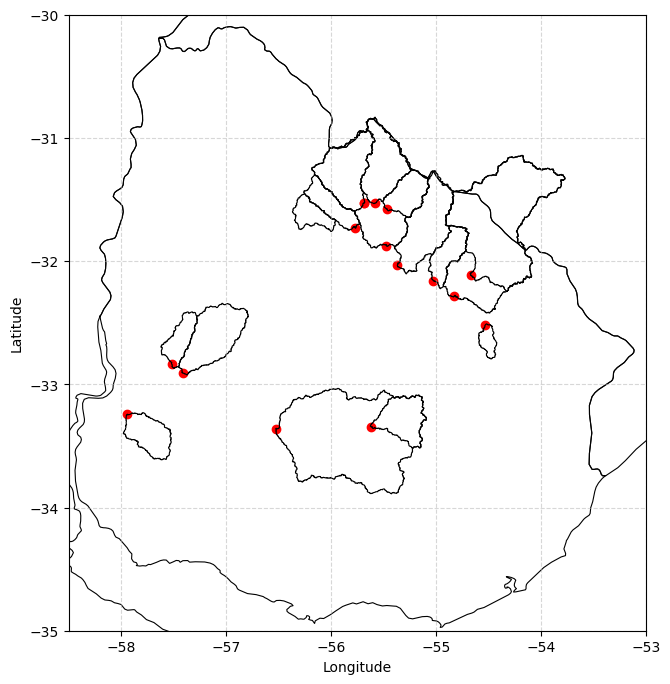

In [20]:
fig, ax = plt.subplots(figsize=(8,8))

# Plot country borders
countries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

# Plot gauges
stations_gdf.plot(ax=ax, marker='o', color='red') #, markersize=50)

# Plot each basin
for z in zip_files:
    if z.stem.lower() == "mercedes":
        continue
    gdf = gpd.read_file(f"zip://{z}")
    gdf.plot(ax=ax, edgecolor="k", facecolor="none", linewidth=0.8)

# ax.set_title("Basin Shapefiles")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

# ---- Limit map to Uruguay approximate bounds ----
# Uruguay approx: lon -58.5 to -53, lat -35 to -30
ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)

plt.show()

# Precipitation gauges

In [21]:
precipitation_gauges=pd.read_excel("./COORDENADAS_filtradas.xlsx")
precipitation_gauges.head()

,lat,lon,Estacion,Departamento,Tipo,Adm
0,-33.72,-53.55,18 de Julio,Rocha,Convencional,INUMET
1,-34.36,-54.06,19 de Abril,Rocha,Convencional,INUMET
2,-34.41,-56.39,25 de Agosto,Florida,Convencional,INUMET
3,-31.87,-54.16,Acegua,Cerro Largo,Convencional,INUMET
4,-32.40,-56.18,Achar,Tacuarembó,Convencional,INUMET


In [22]:
# Create geometry column from lat/lon
precip_geometry = [Point(xy) for xy in zip(precipitation_gauges['lon'], precipitation_gauges['lat'])]

# Convert to GeoDataFrame
precip_stations_gdf = gpd.GeoDataFrame(precipitation_gauges, geometry=precip_geometry)

precip_stations_gdf.head()

,lat,lon,Estacion,Departamento,Tipo,Adm,geometry
0,-33.72,-53.55,18 de Julio,Rocha,Convencional,INUMET,POINT (-53.55 -33.72)
1,-34.36,-54.06,19 de Abril,Rocha,Convencional,INUMET,POINT (-54.06 -34.36)
2,-34.41,-56.39,25 de Agosto,Florida,Convencional,INUMET,POINT (-56.39 -34.41)
3,-31.87,-54.16,Acegua,Cerro Largo,Convencional,INUMET,POINT (-54.16 -31.87)
4,-32.40,-56.18,Achar,Tacuarembó,Convencional,INUMET,POINT (-56.18 -32.4)


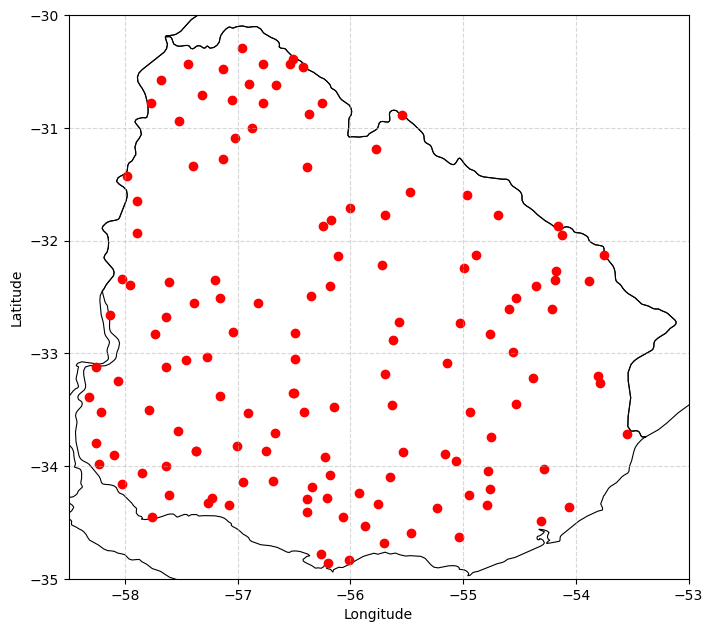

In [23]:
fig, ax = plt.subplots(figsize=(8,8))

# Plot country borders
countries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

# Plot gauges
precip_stations_gdf.plot(ax=ax, marker='o', color='red') #, markersize=50)

# ax.set_title("Basin Shapefiles")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

# ---- Limit map to Uruguay approximate bounds ----
# Uruguay approx: lon -58.5 to -53, lat -35 to -30
ax.set_xlim(-58.5, -53)
ax.set_ylim(-35, -30)

plt.show()